# **Модульна контрольна робота № 1**

In [43]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

### 1. Завантаження зображення

In [44]:
img = cv2.imread('document.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray) / 255

rows, cols = gray.shape

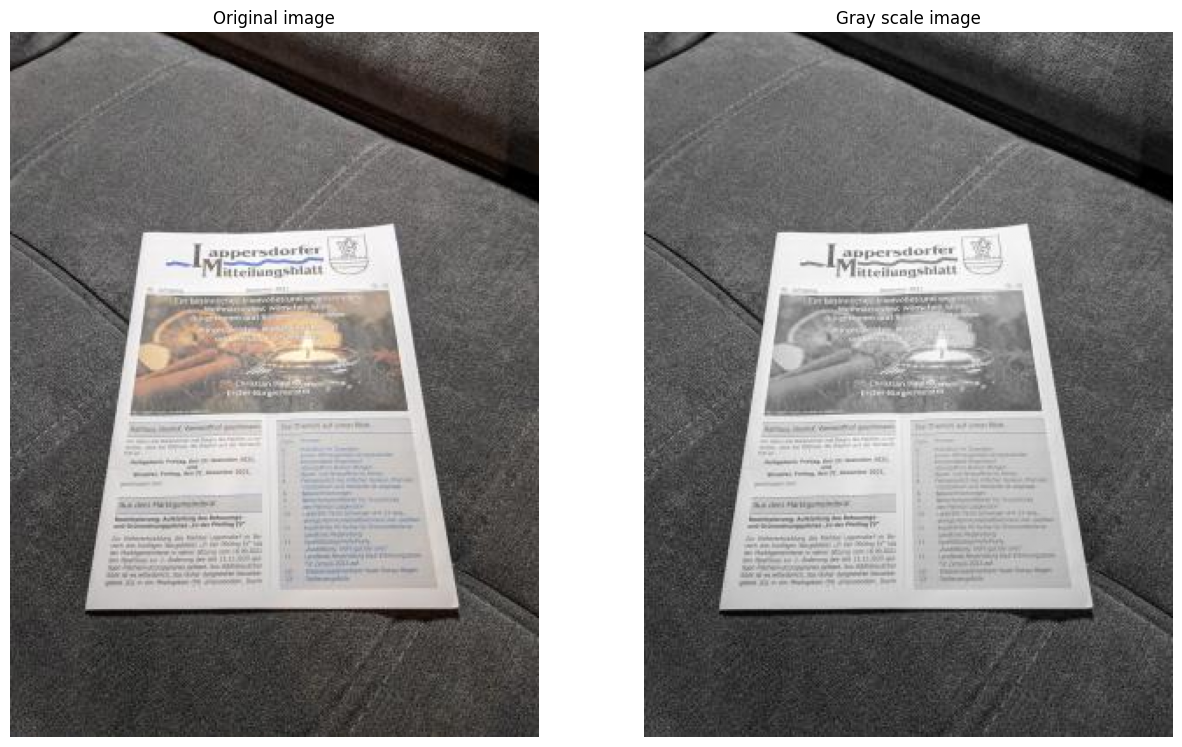

In [45]:
plt.subplot(121)
plt.imshow(img_rgb)
plt.title('Original image')
plt.axis('off')

plt.subplot(122)
plt.imshow(gray, cmap='gray')
plt.title('Gray scale image')
plt.axis('off')

plt.show()

### 2. Harris Corner Detector

In [46]:
cornerness = cv2.cornerHarris(gray, 2, 3, 0.04)
cornerness[cornerness < 0] = 0
cornerness = np.log(cornerness + 1e-6)

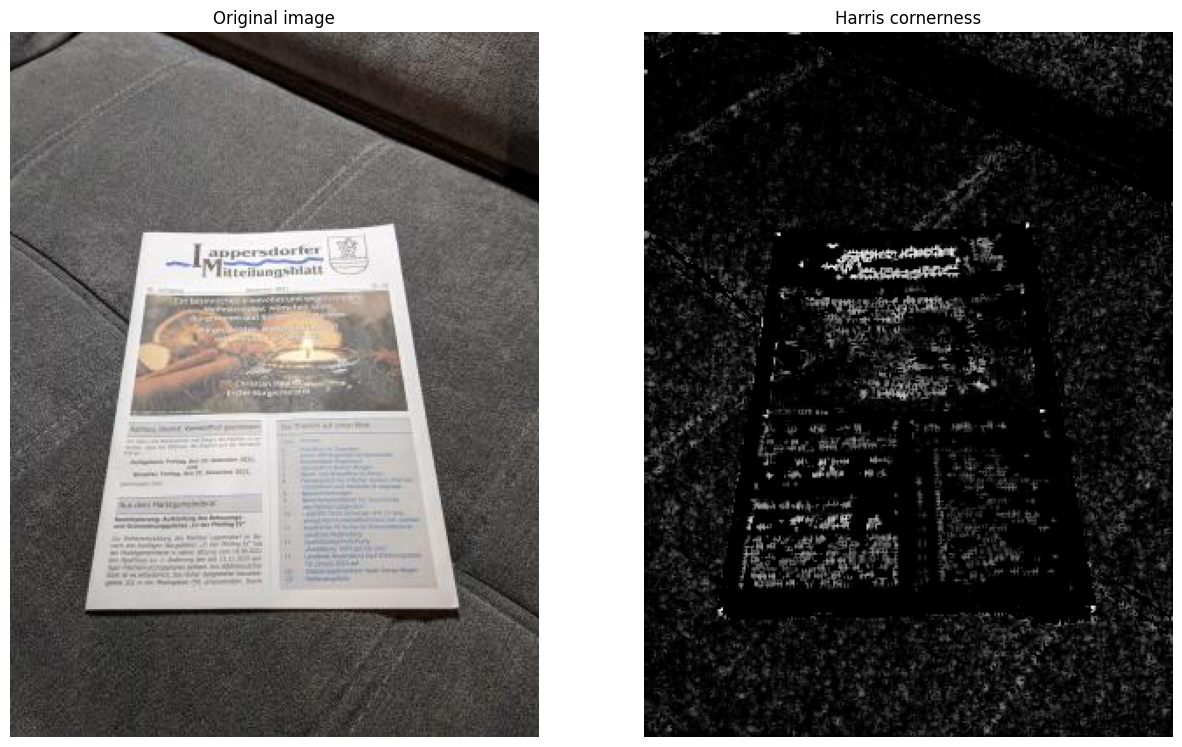

In [47]:
plt.subplot(121)
plt.imshow(img_rgb)
plt.title('Original image')
plt.axis('off')

plt.subplot(122)
plt.imshow(cornerness, cmap='gray')
plt.title('Harris cornerness')
plt.axis('off')

plt.show()

### 3. Виявлення чотирьох кутів документа

In [48]:
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None

quad_size = 7

for r in range(quad_size, rows - quad_size):
    for c in range(quad_size, cols - quad_size):

        if cornerness[r, c] < -7:
            continue
        
        block = 255 * gray[ r - quad_size:r + quad_size + 1, c - quad_size:c + quad_size + 1]

        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[0:quad_size, quad_size + 1:]
        quad_bottom_left = block[quad_size + 1:, 0:quad_size]
        quad_bottom_right = block[quad_size + 1:, quad_size + 1:]

        descriptor = (np.mean(quad_bottom_right) - np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_left) )

        if descriptor > th_top_left:
            th_top_left = descriptor
            opt_top_left = (c, r)

        descriptor = (np.mean(quad_bottom_left) - np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_right))

        if descriptor > th_top_right:
            th_top_right = descriptor
            opt_top_right = (c, r)

        descriptor = (np.mean(quad_top_right) - np.mean(quad_top_left) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right))

        if descriptor > th_bottom_left:
            th_bottom_left = descriptor
            opt_bottom_left = (c, r)

        descriptor = (np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right))

        if descriptor > th_bottom_right:
            th_bottom_right = descriptor
            opt_bottom_right = (c, r)


In [49]:
out = img_rgb.copy()

def draw_corner_square(image, point, size = 7):

    c, r = point
    
    x1 = c - size
    y1 = r - size
    x2 = c + size
    y2 = r + size

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    cv2.line(image, (c, y1), (c, y2), (255, 0, 0), 2 )
    cv2.line(image, (x1, r), (x2, r), (255, 0, 0), 2 )

    return image

### 4. Результат

In [50]:
print("Top-left:", opt_top_left)
print("Top-right:", opt_top_right)
print("Bottom-left:", opt_bottom_left)
print("Bottom-right:", opt_bottom_right)

Top-left: (76, 115)
Top-right: (219, 111)
Bottom-left: (43, 330)
Bottom-right: (256, 329)


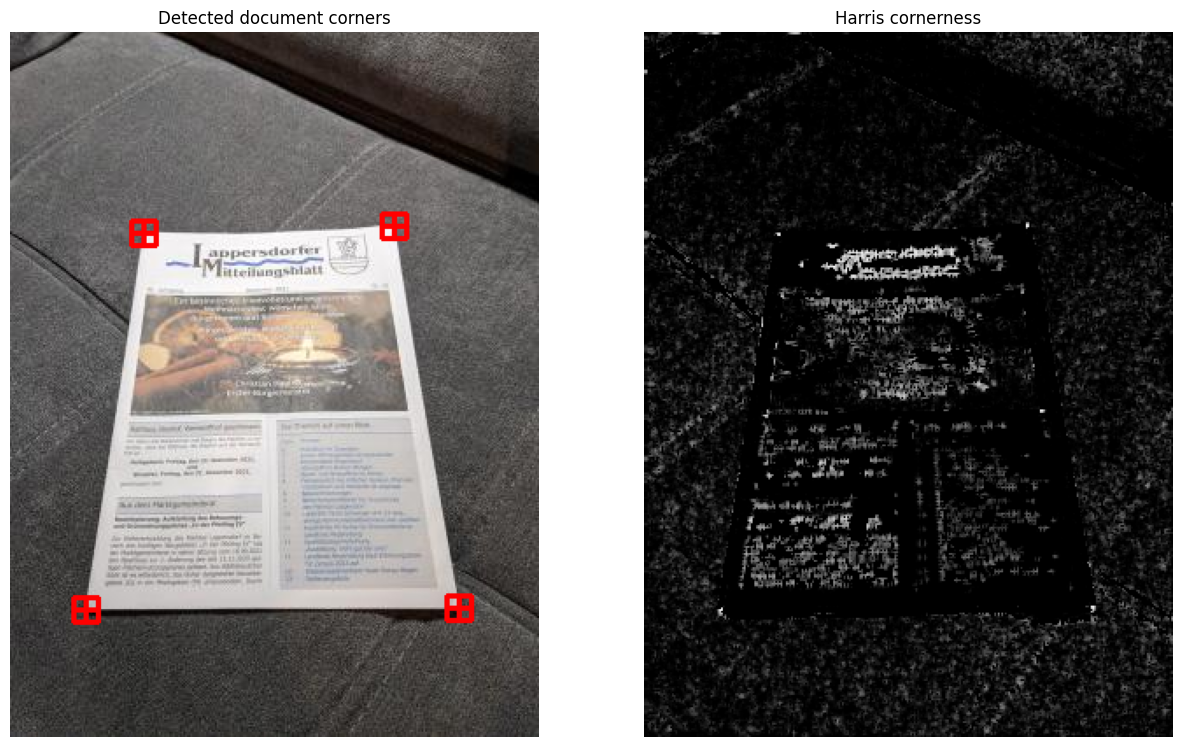

In [ ]:
out = draw_corner_square(out, opt_top_left, quad_size)
out = draw_corner_square(out, opt_top_right, quad_size)
out = draw_corner_square(out, opt_bottom_left, quad_size)
out = draw_corner_square(out, opt_bottom_right, quad_size)

plt.subplot(121)
plt.imshow(out)
plt.title('Detected document corners')
plt.axis('off')

plt.subplot(122)
plt.imshow(cornerness, cmap='gray')
plt.title('Harris cornerness')
plt.axis('off')

plt.show()